In [1]:
import shap
import joblib
import pandas as pd
import pickle

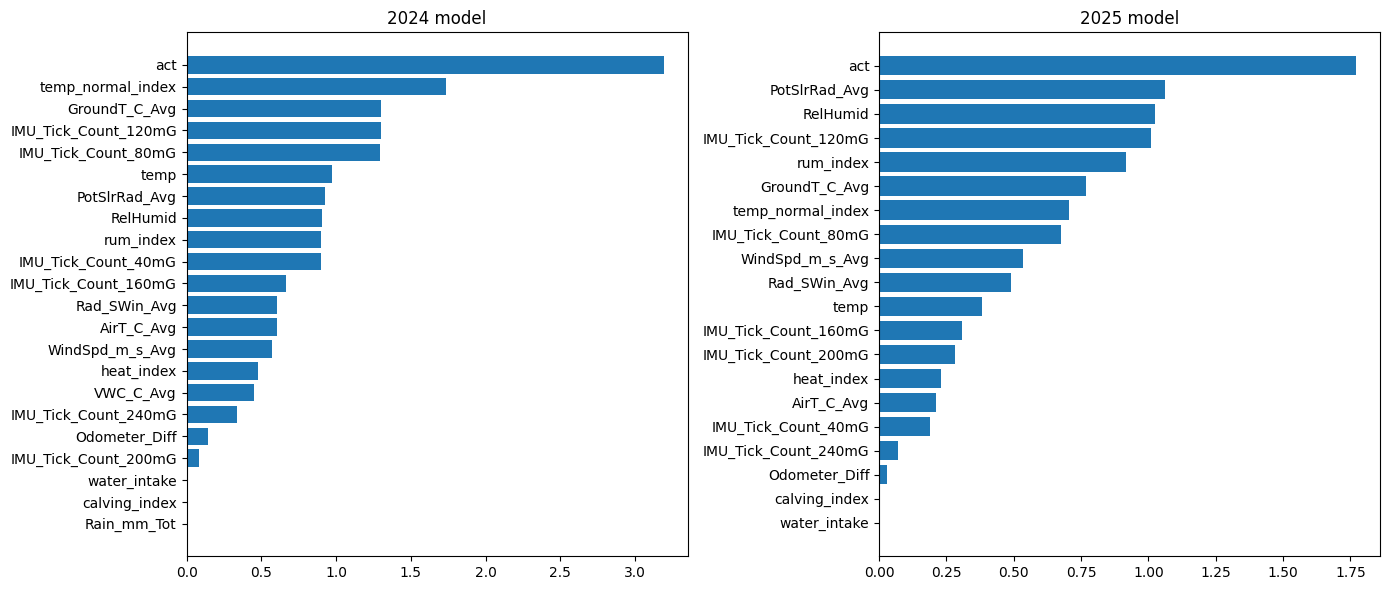

In [2]:
import joblib
import pandas as pd
import shap
import numpy as np

drop_cols = ['animal_id', 'Stehen/Liegen', 'datetime']


# -----------------------
# LOAD 2024
# -----------------------

# -----------------------
# 1. LOAD 2024 MODEL + DATA
# -----------------------
model_24 = joblib.load('/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/exp_5_FINAL_merged_collar_herde_weather_bolus/xgboost_seed_43_exp_5_FINAL_merged_collar_herde_weather_bolus.joblib')
X_test_24  = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/exp_5_FINAL_merged_collar_herde_weather_bolus/test/X_test_exp_5_FINAL_merged_collar_herde_weather_bolus.pkl")

X_train_24 = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/exp_5_FINAL_merged_collar_herde_weather_bolus/train/X_train_exp_5_FINAL_merged_collar_herde_weather_bolus.pkl")

# -----------------------
# align to MODEL 24 features (IMPORTANT)
feat_24 = model_24.get_booster().feature_names
X_test_24 = X_test_24.reindex(columns=feat_24).fillna(0)


# -----------------------
# LOAD 2025
# -----------------------

# -----------------------
# 2. LOAD 2025 MODEL + DATA
# -----------------------
model_25 = joblib.load('/Users/luka/priv_projects/moomotion/data/final_results/final_experiment/FINAL/xgboost_seed_exp_8_2025_merged_collar_herde_bolus_weather_new_cows_test.joblib')

X_train_25 = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/final_results/final_experiment/FINAL/train/X_train_exp_8_2025_merged_collar_herde_bolus_weather_new_cows_test.pkl")
X_test_25  = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/final_results/final_experiment/FINAL/test/X_test_exp_8_2025_merged_collar_herde_bolus_weather_new_cows_test.pkl")

# align to MODEL 25 features (CRITICAL FIX)
feat_25 = model_25.get_booster().feature_names
X_test_25 = X_test_25.reindex(columns=feat_25).fillna(0)


# -----------------------
# SHAP
# -----------------------
explainer_24 = shap.TreeExplainer(model_24)
explainer_25 = shap.TreeExplainer(model_25)

shap_24 = explainer_24(X_test_24)
shap_25 = explainer_25(X_test_25)


# -----------------------
# MEAN |SHAP|
# -----------------------
mean_24 = np.abs(shap_24.values).mean(axis=0)
mean_25 = np.abs(shap_25.values).mean(axis=0)

df_24 = pd.DataFrame({
    "feature": feat_24,
    "importance": mean_24
}).sort_values("importance")

df_25 = pd.DataFrame({
    "feature": feat_25,
    "importance": mean_25
}).sort_values("importance")


# -----------------------
# PLOT
# -----------------------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

ax[0].barh(df_24["feature"], df_24["importance"])
ax[0].set_title("2024 model")

ax[1].barh(df_25["feature"], df_25["importance"])
ax[1].set_title("2025 model")

plt.tight_layout()
plt.show()

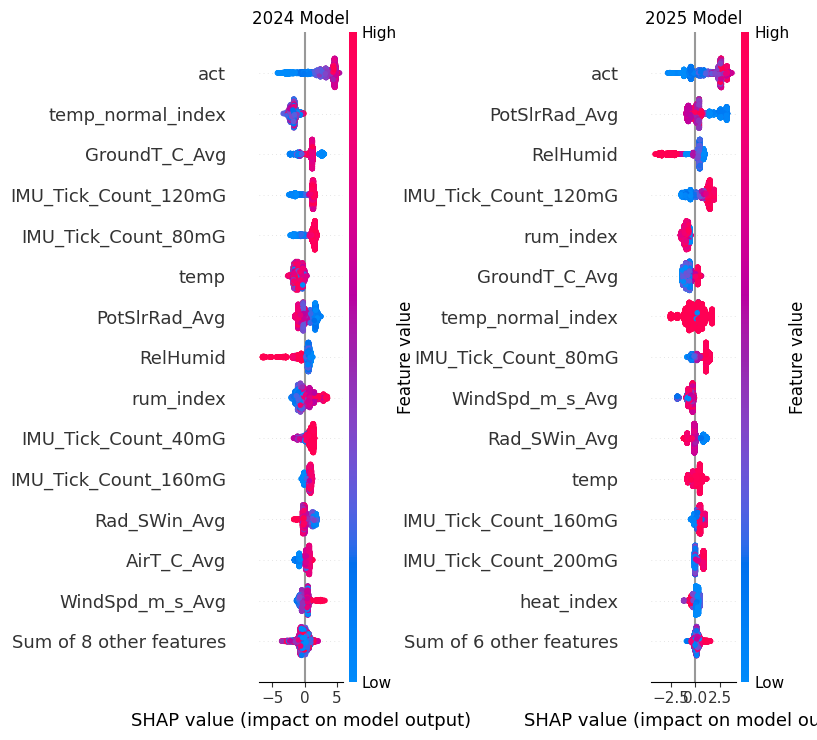

In [3]:
import shap
import numpy as np
import matplotlib.pyplot as plt


# -----------------------
# CONFIG
# -----------------------
DROP_COLS = ['animal_id', 'Stehen/Liegen', 'datetime']
MISSING_2025 = ['Rain_mm_Tot', 'VWC_C_Avg']


def prepare_X(X, model, missing_cols=None):
    """
    Align dataframe to model feature space safely.
    """
    X = X.copy()

    # drop non-features if present
    X = X.drop(columns=DROP_COLS, errors="ignore")

    # add explicitly missing columns (e.g. 2025 case)
    if missing_cols is not None:
        for col in missing_cols:
            if col not in X.columns:
                X[col] = 0

    # align strictly to model features
    booster = model.get_booster()
    feat_names = booster.feature_names

    X = X.reindex(columns=feat_names).fillna(0)

    return X


# -----------------------
# PREPARE DATA
# -----------------------
X_24 = prepare_X(X_test_24, model_24)
X_25 = prepare_X(X_test_25, model_25, missing_cols=MISSING_2025)


# -----------------------
# SHAP VALUES
# -----------------------
explainer_24 = shap.TreeExplainer(model_24)
explainer_25 = shap.TreeExplainer(model_25)

shap_24 = explainer_24(X_24)
shap_25 = explainer_25(X_25)


# -----------------------
# PLOT SIDE-BY-SIDE
# -----------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# 2024
plt.sca(axes[0])
shap.plots.beeswarm(shap_24, max_display=15, show=False)
axes[0].set_title("2024 Model", fontsize=12)

# 2025
plt.sca(axes[1])
shap.plots.beeswarm(shap_25, max_display=15, show=False)
axes[1].set_title("2025 Model", fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
feature_name_map = {
    "IMU_Tick_Count_40mG": "Low activity (40mG)",
    "IMU_Tick_Count_80mG": "Light movement (80mG)",
    "IMU_Tick_Count_120mG": "Moderate movement (120mG)",
    "IMU_Tick_Count_160mG": "Active movement (160mG)",
    "IMU_Tick_Count_200mG": "High movement (200mG)",
    "IMU_Tick_Count_240mG": "Very high movement (240mG)",

    "act": "Bolus activity",
    "calving_index": "Calving index",
    "temp": "Body temperature",
    "rum_index": "Rumination activity",
    "temp_normal_index": "Temperature deviation",
    "heat_index": "Heat stress index",

    "water_intake": "Water intake",

    "AirT_C_Avg": "Air temperature",
    "GroundT_C_Avg": "Ground temperature",
    "RelHumid": "Relative humidity",
    "Rad_SWin_Avg": "Solar radiation",
    "WindSpd_m_s_Avg": "Wind speed",
    "PotSlrRad_Avg": "Potential solar radiation",

    "Odometer_Diff": "Movement distance change"
}

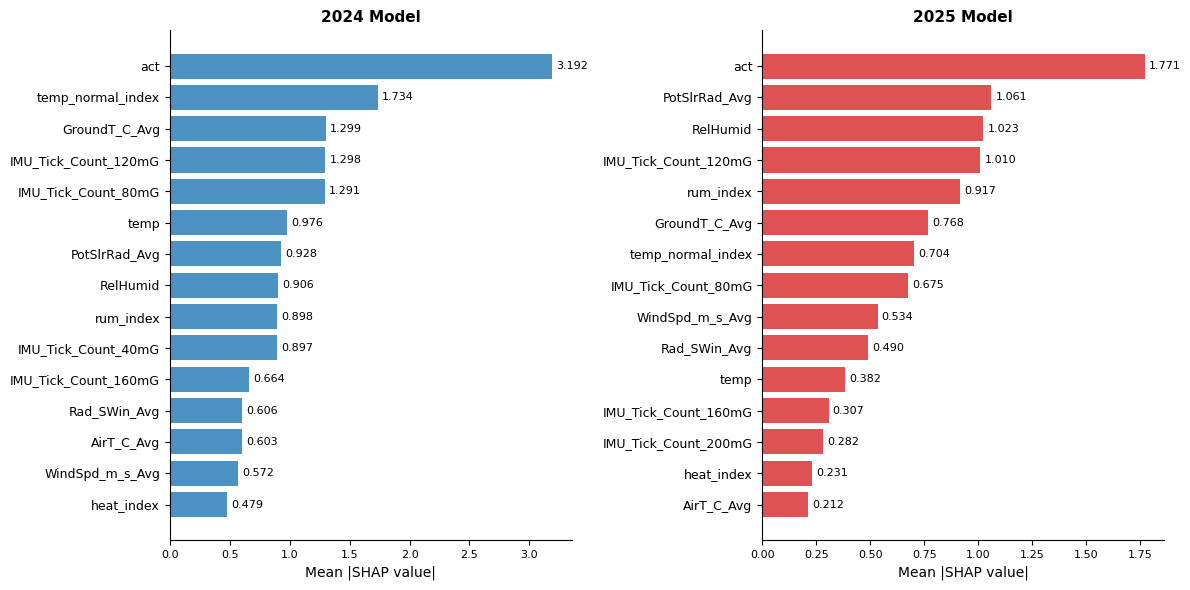

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# -----------------------
# CONFIG
# -----------------------
DROP_COLS = ['animal_id', 'Stehen/Liegen', 'datetime']
MISSING_2025 = ['Rain_mm_Tot', 'VWC_C_Avg']


def prepare_X(X, model, missing_cols=None):
    X = X.copy()
    X = X.drop(columns=DROP_COLS, errors="ignore")
    if missing_cols is not None:
        for col in missing_cols:
            if col not in X.columns:
                X[col] = 0
    booster = model.get_booster()
    feat_names = booster.feature_names
    X = X.reindex(columns=feat_names).fillna(0)
    return X


# -----------------------
# LOAD DATA & MODELS
# -----------------------
model_24 = joblib.load('/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/exp_5_FINAL_merged_collar_herde_weather_bolus/xgboost_seed_43_exp_5_FINAL_merged_collar_herde_weather_bolus.joblib')
X_test_24  = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/final_results/NO_FEATURE_ENGINEERING/exp_5_FINAL_merged_collar_herde_weather_bolus/test/X_test_exp_5_FINAL_merged_collar_herde_weather_bolus.pkl")

model_25 = joblib.load('/Users/luka/priv_projects/moomotion/data/final_results/final_experiment/FINAL/xgboost_seed_exp_8_2025_merged_collar_herde_bolus_weather_new_cows_test.joblib')
X_test_25  = pd.read_pickle("/Users/luka/priv_projects/moomotion/data/final_results/final_experiment/FINAL/test/X_test_exp_8_2025_merged_collar_herde_bolus_weather_new_cows_test.pkl")

X_24 = prepare_X(X_test_24, model_24)
X_25 = prepare_X(X_test_25, model_25, missing_cols=MISSING_2025)


# -----------------------
# SHAP VALUES
# -----------------------
explainer_24 = shap.TreeExplainer(model_24)
explainer_25 = shap.TreeExplainer(model_25)

shap_24 = explainer_24(X_24)
shap_25 = explainer_25(X_25)



# =======================
# OPTION 2: Side-by-side mean |SHAP| bar chart (top 15 features each)
# =======================
TOP_N_BAR = 15

def mean_abs_shap(sv, feature_names, top_n):
    vals = np.abs(sv.values).mean(axis=0)
    return (
        pd.Series(vals, index=feature_names)
        .nlargest(top_n)
        .iloc[::-1]  # ascending so most important is on top in barh
    )

imp_24 = mean_abs_shap(shap_24, X_24.columns, TOP_N_BAR)
imp_25 = mean_abs_shap(shap_25, X_25.columns, TOP_N_BAR)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, imp, title, color in [
    (axes[0], imp_24, "2024 Model", "#1f77b4"),
    (axes[1], imp_25, "2025 Model", "#d62728"),
]:
    bars = ax.barh(imp.index, imp.values, color=color, alpha=0.8)
    ax.set_xlabel("Mean |SHAP value|", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis="y", labelsize=9)
    ax.tick_params(axis="x", labelsize=8)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()



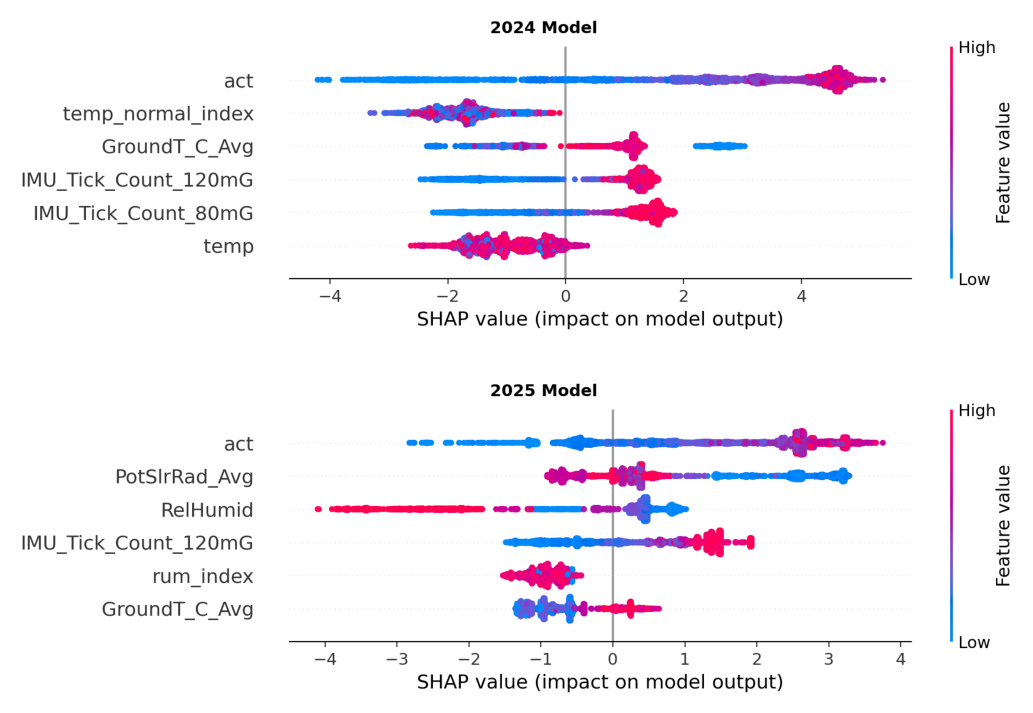

In [6]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io

TOP_N = 6

def shap_beeswarm_to_image(sv, X, top_n, title):
    """Render a shap summary_plot to a numpy image array."""
    mean_abs = np.abs(sv.values).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:top_n]
    sv_filtered = sv[:, top_idx]

    # Let shap create its own figure
    shap.summary_plot(
        sv_filtered.values,
        X.iloc[:, top_idx],
        plot_type="dot",
        max_display=top_n,
        show=False,
        color_bar=True,
        plot_size=(10, 3),
    )
    fig = plt.gcf()
    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=200)
    buf.seek(0)
    img = mpimg.imread(buf)
    plt.close(fig)
    return img


img_24 = shap_beeswarm_to_image(shap_24, X_24, TOP_N, "2024 Model")
img_25 = shap_beeswarm_to_image(shap_25, X_25, TOP_N, "2025 Model")

# Composite into a single figure
fig, axes = plt.subplots(2, 1, figsize=(15, 9))
plt.subplots_adjust(hspace=0.1)

for ax, img in [(axes[0], img_24), (axes[1], img_25)]:
    ax.imshow(img)
    ax.axis("off")

plt.show()

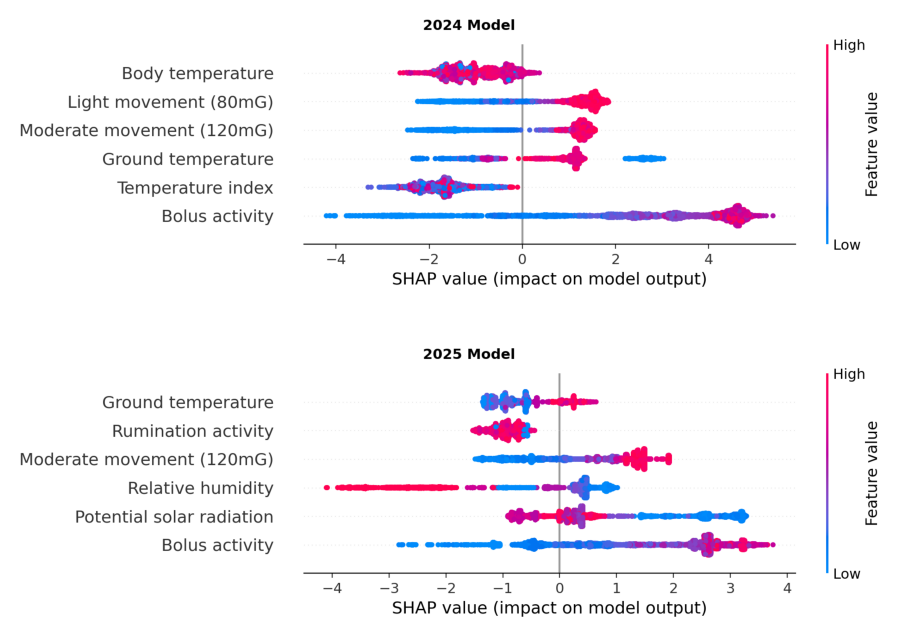

In [7]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import io

TOP_N = 6

# -----------------------
# FEATURE NAME MAP
# -----------------------
feature_name_map = {
    "IMU_Tick_Count_40mG": "Low activity (40mG)",
    "IMU_Tick_Count_80mG": "Light movement (80mG)",
    "IMU_Tick_Count_120mG": "Moderate movement (120mG)",
    "IMU_Tick_Count_160mG": "Active movement (160mG)",
    "IMU_Tick_Count_200mG": "High movement (200mG)",
    "IMU_Tick_Count_240mG": "Very high movement (240mG)",

    "act": "Bolus activity",
    "calving_index": "Calving index",
    "temp": "Body temperature",
    "rum_index": "Rumination activity",
    "temp_normal_index": "Temperature index",
    "heat_index": "Heat stress index",

    "water_intake": "Water intake",

    "AirT_C_Avg": "Air temperature",
    "GroundT_C_Avg": "Ground temperature",
    "RelHumid": "Relative humidity",
    "Rad_SWin_Avg": "Solar radiation",
    "WindSpd_m_s_Avg": "Wind speed",
    "PotSlrRad_Avg": "Potential solar radiation",

    "Odometer_Diff": "Movement distance change"
}


# -----------------------
# GLOBAL FEATURE RANKING (CRITICAL)
# -----------------------
mean_abs_24 = np.abs(shap_24.values).mean(axis=0)
top_idx = np.argsort(mean_abs_24)[::-1][:TOP_N]

def shap_beeswarm_to_image(sv, X, title, top_n):
    # Each year ranks independently — the reordering IS the finding
    mean_abs = np.abs(sv.values).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:top_n]
    # Reverse for summary_plot bottom-to-top rendering
    ordered_idx = top_idx[::-1]

    sv_filtered = sv[:, ordered_idx]
    X_filtered = X.iloc[:, ordered_idx].copy()
    X_filtered.columns = [
        feature_name_map.get(col, col) for col in X_filtered.columns
    ]

    shap.summary_plot(
        sv_filtered.values,
        X_filtered,
        plot_type="dot",
        max_display=top_n,
        show=False,
        color_bar=True,
        plot_size=(10, 3),
        sort=False,
    )

    fig = plt.gcf()
    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.02)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=200)
    buf.seek(0)
    img = mpimg.imread(buf)
    plt.close(fig)
    return img


img_24 = shap_beeswarm_to_image(shap_24, X_24, "2024 Model", TOP_N)
img_25 = shap_beeswarm_to_image(shap_25, X_25, "2025 Model", TOP_N)

# -----------------------
# COMBINE FIGURE
# -----------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
plt.subplots_adjust(hspace=0.15)

for ax, img in zip(axes, [img_24, img_25]):
    ax.imshow(img)
    ax.axis("off")

plt.savefig("shap_beeswarm_stacked.pdf", bbox_inches="tight", dpi=300)
plt.show()